# AAV5 -- Plafond de bruit sur `viab`, population sans borne de comptage (7m8 retiré seul)

Variante d'`AAV5_viab_noise_ceiling.ipynb` : celui-là travaillait sur `AAV5_organoides_sorted.csv`
(filtre historique `10 <= compte_plasmide <= 500` **+** retrait du spike-in 7m8 et de ses
« déclinaisons » -- les variants à `hamming <= 2` de la séquence de référence `LGETTRP`, presque
identiques au 7m8 et donc probablement des erreurs de lecture/synthèse plutôt que de vrais variants
distincts). Ici, on retire **seulement** le 7m8 et ses déclinaisons -- **aucune borne de comptage**
sur `compte_plasmide` : population maximale, contamination connue exclue, rien d'autre.

CSV utilisé : `AAV5_organoides_sorted_viab.csv` (écrit dans `AAV5_viab_sorting.ipynb`, 5 044 820
lignes, 90.2% du brut -- retrait 7m8 hamming<=2 + retrait des seuls comptages nuls, où le ratio
`virus/plasmide` est de toute façon indéfini). Rappel de la conclusion de ce notebook-là : cette
population donne une distribution de `viab` PLUS fragmentée (6 pics vs 4, moins bien séparée en 2
modes) que la population bornée -- pas retenue comme CSV de référence pour le TRI (bimodalité
fit/non-fit moins nette), mais rien n'empêche de calculer un plafond de bruit dessus : c'est une
question différente (quantité de bruit, pas qualité de la séparation bimodale).

Même méthode qu'`AAV5_viab_noise_ceiling.ipynb` (voir aussi
`Modelization_V2/docs/NGS_noise_ceiling_reliability.tex` pour les dérivations complètes), avec une
**correction** apportée ici : les comptages AAV5 sont des multiples exacts de 0.5, or le notebook
original castait `plasmid.astype(np.int64)` avant le thinning binomial -- une troncature qui perd
jusqu'à 0.5 de comptage à chaque fois. Corrigé ici : on double les comptages (`x*2`, toujours un
entier exact), on scinde cet entier, puis on divise par 2.

Hors périmètre (comme les autres notebooks de cette famille) : loss Poisson, dithering.
**Pas exécuté automatiquement** -- laissé pour que tu le lances toi-même.


In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"   # avant tout import jax (via analysisV1/RegressionV1)
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
LIB = _root / "lib"
from analysisV1 import AA_LABELS, pearson

CSV = Path("AAV5_organoides_sorted_viab.csv")
if not CSV.exists():
    CSV = _root / "notebooks/notebooks/Selectivity/AAV5/AAV5_organoides_sorted_viab.csv"
assert CSV.exists(), CSV

viab_col = "log2_enrichissement_virus_sur_plasmide"
use_cols = ["sequence", "compte_plasmide", "compte_virus", viab_col]
dtypes = {"sequence": "string", "compte_plasmide": "float32", "compte_virus": "float32", viab_col: "float32"}
df = pd.read_csv(CSV, usecols=use_cols, dtype=dtypes)
df["sequence"] = df["sequence"].astype("string")
print(df.shape)
df.head()


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(5044820, 4)


,sequence,compte_plasmide,compte_virus,log2_enrichissement_virus_sur_plasmide
0,TEVDRMT,36.5,0.5,-4.928953
1,VPQEVVR,8.5,50.5,3.831620
2,TGRSDAQ,10.0,8.5,1.026406
3,PIRINSN,14.5,1.0,-2.597110
4,GDTIAMV,8.5,6.0,0.758371


## 1. Cible recalculée (`eps=0.5`)

In [2]:
EPS = 0.5   # convention projet -- jamais +1

plasmid = df["compte_plasmide"].to_numpy(np.float64)
virus   = df["compte_virus"].to_numpy(np.float64)

target_ln   = np.log((virus + EPS) / (plasmid + EPS))
target_log2 = target_ln / np.log(2)

target_csv = df[viab_col].to_numpy(np.float64)
r_vs_csv = pearson(target_log2, target_csv)
print(f"n = {len(df):,}")
print(f"r(cible recalculée eps=0.5, colonne CSV fournie) = {r_vs_csv:+.4f}")


n = 5,044,820
r(cible recalculée eps=0.5, colonne CSV fournie) = +0.9978


## 2. Plafond analytique -- correction d'atténuation (Poisson delta-method)

In [3]:
noise_var_ln = 1.0 / (virus + EPS) + 1.0 / (plasmid + EPS)

mean_noise_var = noise_var_ln.mean()
observed_var   = target_ln.var()
rho            = 1.0 - mean_noise_var / observed_var
ceiling_r      = np.sqrt(max(rho, 0.0))

print(f"var(bruit de comptage), moyenne sur {len(df):,} variants : {mean_noise_var:.4f}")
print(f"var(cible observée)                                     : {observed_var:.4f}")
print(f"fiabilité rho = 1 - bruit/observé                       : {rho:.4f}")
print(f"plafond analytique sqrt(rho) : {ceiling_r:.4f}")

noise_var_log2 = noise_var_ln / (np.log(2) ** 2)
rho_log2 = 1.0 - noise_var_log2.mean() / target_log2.var()
assert abs(rho_log2 - rho) < 1e-9, (rho_log2, rho)
print("(vérifié : rho identique en base log2)")


var(bruit de comptage), moyenne sur 5,044,820 variants : 0.3594
var(cible observée)                                     : 2.5998
fiabilité rho = 1 - bruit/observé                       : 0.8618
plafond analytique sqrt(rho) : 0.9283
(vérifié : rho identique en base log2)


## 3. Plafond empirique -- thinning binomial (corrigé pour le quantum 0.5) + Spearman-Brown

`AAV5_viab_noise_ceiling.ipynb` castait les comptages en `int64` avant thinning (`plasmid.astype(np.int64)`), ce qui tronque silencieusement jusqu'à 0.5 unité à chaque valeur (comptages toujours multiples exacts de 0.5 sur AAV5). Corrigé ici : on multiplie par 2 pour obtenir des entiers exacts, on scinde, puis on divise par 2.

In [4]:
def split_half_r(plasmid, virus, eps, rng):
    p2 = np.rint(plasmid * 2).astype(np.int64)   # comptages x2 -> entiers exacts (quantum 0.5 -> 1)
    v2 = np.rint(virus * 2).astype(np.int64)
    p2_a = rng.binomial(p2, 0.5)
    v2_a = rng.binomial(v2, 0.5)
    p_a, p_b = p2_a / 2.0, (p2 - p2_a) / 2.0
    v_a, v_b = v2_a / 2.0, (v2 - v2_a) / 2.0
    t_a = np.log((v_a + eps) / (p_a + eps))
    t_b = np.log((v_b + eps) / (p_b + eps))
    return pearson(t_a, t_b)

K = 30
rng = np.random.default_rng(0)
r_splits = np.array([split_half_r(plasmid, virus, EPS, rng) for _ in range(K)])
rho_half = r_splits.mean()

rho_full_empirical = 2 * rho_half / (1 + rho_half)   # Spearman-Brown
ceiling_r_empirical = np.sqrt(max(rho_full_empirical, 0.0))

print(f"corr(moitié A, moitié B), moyenne sur {K} tirages : {rho_half:.4f} +/- {r_splits.std():.4f}")
print(f"fiabilité pleine profondeur (Spearman-Brown)      : {rho_full_empirical:.4f}")
print(f"plafond empirique sqrt(rho_full)                  : {ceiling_r_empirical:.4f}")
print(f"(à comparer au plafond analytique de la section 2 : {ceiling_r:.4f})")


corr(moitié A, moitié B), moyenne sur 30 tirages : 0.9111 +/- 0.0001
fiabilité pleine profondeur (Spearman-Brown)      : 0.9535
plafond empirique sqrt(rho_full)                  : 0.9765
(à comparer au plafond analytique de la section 2 : 0.9283)


## 4. Potts fit direct sur cette population (fraîchement fitté, pas de poids réutilisé)

Aucun poids Potts n'a été fitté spécifiquement sur cette population (sans borne) ailleurs dans le projet -- les poids `aav5_{F,J}_viab_potts_sorted_*` existants viennent tous d'`AAV5_organoides_sorted.csv` (bornée `[10,500]`), une population différente. Fit `lam=0` (non régularisé) ici, même recette que les autres notebooks AAV5 (la CV y dégénère systématiquement vers des lambda énormes qui écrasent F/J).

In [5]:
import RegressionV1 as R
from sklearn.model_selection import train_test_split

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i
L = 7
seq_matrix = lut[np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8)].reshape(len(df), L)

def score_FJ(seq, F, J):
    F, J = np.asarray(F, np.float64), np.asarray(J, np.float64)
    s = F[seq, np.arange(L)].sum(axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            s = s + J[i, j, seq[:, i], seq[:, j]]
    return s

w_all = 1.0 / noise_var_ln   # meme poids inverse-variance que partout ailleurs dans le projet

idx = np.flatnonzero(np.isfinite(target_log2))
N_FIT, N_EVAL = 80_000, 150_000
RNG = np.random.default_rng(0)
tr, te = train_test_split(idx, test_size=0.5, random_state=0)
fit_i  = tr if len(tr) <= N_FIT  else RNG.choice(tr, N_FIT,  replace=False)
eval_i = te if len(te) <= N_EVAL else RNG.choice(te, N_EVAL, replace=False)
print(f"n_fit={len(fit_i):,}  n_eval={len(eval_i):,}")

F, J, rank, info = R.fit_weights_potts_from_data(
    seq_matrix[fit_i], target_log2[fit_i], sample_weight=w_all[fit_i], lam=0.0, verbose=False)
pred_eval = score_FJ(seq_matrix[eval_i], F, J)
r_heldout = pearson(target_log2[eval_i], pred_eval)
print(f"rank design : {rank}/8541")
print(f"held-out r (lam=0, cette population) = {r_heldout:+.3f}")


n_fit=80,000  n_eval=150,000
rank design : 4889/8541
held-out r (lam=0, cette population) = +0.223


In [6]:
rows = [
    ("Potts (lam=0, cette population, sans borne)  -- held-out", r_heldout),
    ("PLAFOND analytique sqrt(rho)  (section 2)", ceiling_r),
    ("PLAFOND empirique sqrt(rho) split-half Spearman-Brown  (section 3)", ceiling_r_empirical),
    ("[pour mémoire] Potts held-out sur AAV5_organoides_sorted.csv borné [10,500]", 0.204),
]
tbl = pd.DataFrame(rows, columns=["méthode", "r"]).set_index("méthode")
print(tbl.to_string(float_format=lambda x: f"{x:+.3f}"))

best_ceiling = max(ceiling_r, ceiling_r_empirical)
frac = r_heldout / best_ceiling if best_ceiling > 0 else float("nan")
print(f"\nr held-out / plafond estimé (cette population) = {frac:.1%}")
if frac >= 0.85:
    print("-> déjà proche du plafond de bruit sur cette population aussi.")
elif frac >= 0.5:
    print("-> marge intermédiaire.")
else:
    print("-> écart important au plafond.")


                                                                                 r
méthode                                                                           
Potts (lam=0, cette population, sans borne)  -- held-out                    +0.223
PLAFOND analytique sqrt(rho)  (section 2)                                   +0.928
PLAFOND empirique sqrt(rho) split-half Spearman-Brown  (section 3)          +0.976
[pour mémoire] Potts held-out sur AAV5_organoides_sorted.csv borné [10,500] +0.204

r held-out / plafond estimé (cette population) = 22.9%
-> écart important au plafond.


## 5. Compromis profondeur de comptage / plafond (même sweep, population sans borne)

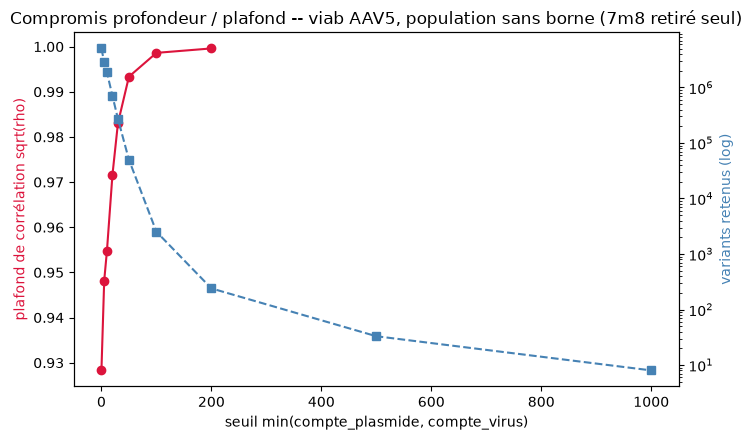

,"min(plasmide,virus) >=",n_variants,rho,plafond sqrt(rho)
0,0,5044820,0.861754,0.928307
1,5,2836143,0.898967,0.948139
2,10,1865174,0.911600,0.954777
3,20,706295,0.943950,0.971571
4,30,271557,0.966365,0.983038
5,50,49867,0.986732,0.993344
6,100,2515,0.997230,0.998614
7,200,240,0.999189,0.999594
8,500,33,NaN,NaN
9,1000,8,NaN,NaN


In [7]:
def ceiling_at_threshold(min_count):
    mask = (plasmid >= min_count) & (virus >= min_count)
    n = int(mask.sum())
    if n < 100:
        return n, np.nan, np.nan
    t = target_ln[mask]
    nv = noise_var_ln[mask]
    rho_t = 1.0 - nv.mean() / t.var()
    return n, rho_t, np.sqrt(max(rho_t, 0.0))

thresholds = [0, 5, 10, 20, 30, 50, 100, 200, 500, 1000]
rows = [(t, *ceiling_at_threshold(t)) for t in thresholds]
sweep = pd.DataFrame(rows, columns=["min(plasmide,virus) >=", "n_variants", "rho", "plafond sqrt(rho)"])

fig, ax1 = plt.subplots(figsize=(7.5, 4.5))
ax2 = ax1.twinx()
ax1.plot(sweep["min(plasmide,virus) >="], sweep["plafond sqrt(rho)"], "o-", color="crimson", label="plafond sqrt(rho)")
ax2.plot(sweep["min(plasmide,virus) >="], sweep["n_variants"], "s--", color="steelblue", label="n variants")
ax2.set_yscale("log")
ax1.set_xlabel("seuil min(compte_plasmide, compte_virus)")
ax1.set_ylabel("plafond de corrélation sqrt(rho)", color="crimson")
ax2.set_ylabel("variants retenus (log)", color="steelblue")
ax1.set_title("Compromis profondeur / plafond -- viab AAV5, population sans borne (7m8 retiré seul)")
fig.tight_layout()
plt.show()
sweep


## Lecture

- Cette population (5 044 820 lignes, seul le 7m8 et ses déclinaisons retirés) est presque 6x plus
  grande que la population bornée `[10,500]` (822 400 lignes -- 3 822 400 en réalité, cf.
  `AAV5_organoides_sorted.csv`) : la comparaison avec le plafond/r held-out de cette dernière montre
  si la borne `[10,500]` gagnait vraiment en fiabilité (plafond plus haut ici, malgré ou grâce à
  l'inclusion de comptages très bas) ou si elle perdait juste du volume pour rien.
- Si le plafond ici (§2/§3) est plus BAS que celui de la population bornée : cohérent avec le
  diagnostic déjà posé dans `AAV5_viab_sorting.ipynb` (en dessous de `compte_plasmide` ~8-10, le
  bruit de comptage domine et noie le signal fit/non-fit) -- la borne inférieure à 10 n'était pas
  arbitraire.
- Le sweep §5 permet de vérifier directement à quel seuil le plafond de cette population rejoint
  celui de la population déjà bornée -- normalement autour de `min(plasmide,virus) ~= 10`, si le
  diagnostic précédent est correct.